In [8]:
import numpy as np
class Perceptron:
  def __init__(self,lr=0.1,epochs=10):
    self.lr=lr;
    self.epochs=epochs
    self.weights=None
    self.bias=None
  def activation(self,x):
    return 1 if x>=0 else 0
  def fit(self,X,y):
    n_features=X.shape[1] #x.0 x.1  lets x=1 x=0
    self.weights=np.zeros(n_features) #w1=0 w2=1
    self.bias=0
    for _ in range(self.epochs):
      for i in range(len(X)):
        linear_output=np.dot(X[i],self.weights)+self.bias #([0,0],[0,0])+0
        y_pred=self.activation(linear_output)
        update=self.lr*(y[i]-y_pred) #error
        self.weights+=update*X[i]  # old_weight+lerning*error*X[i]
        self.bias+=update
  def predict(self,X):
    prediction=[]
    for x in X:
      linear_output=np.dot(x,self.weights)+self.bias
      y_pred=self.activation(linear_output)
      prediction.append(y_pred)
    return prediction



In [9]:
X=np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])
y=np.array([0,0,0,1])
model=Perceptron(lr=0.1,epochs=10)
model.fit(X,y)
prediction=model.predict(X)
print("Prediction: ",prediction)

Prediction:  [0, 0, 0, 1]


In [13]:
import  matplotlib.pyplot as plt
def plot_decision_boundary(X, y, model, title):
    plt.figure()

    # plot points
    for i in range(len(X)):
        if y[i] == 0:
            plt.scatter(X[i][0], X[i][1], color='red')
        else:
            plt.scatter(X[i][0], X[i][1], color='green')

    # decision boundary
    x_vals = np.linspace(-1, 2, 100)
    y_vals = -(model.weights[0]*x_vals + model.bias) / model.weights[1]

    plt.plot(x_vals, y_vals)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

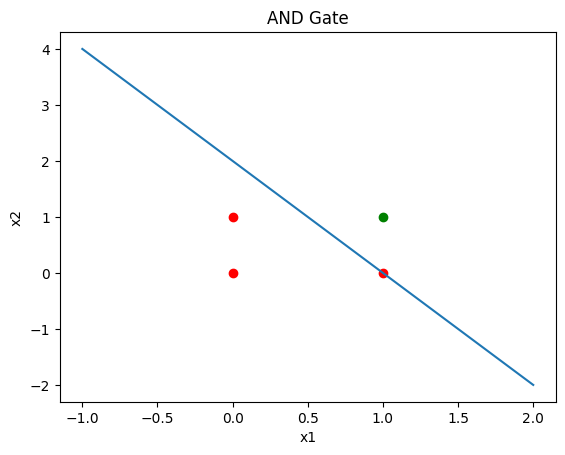

In [14]:
plot_decision_boundary(X,y,model,"AND Gate")

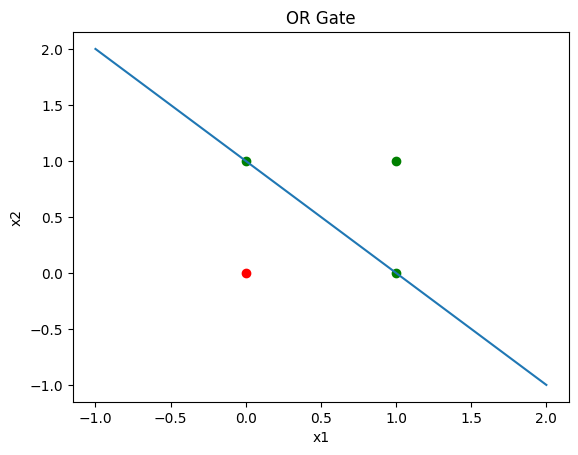

In [15]:
y = np.array([0,1,1,1])

model = Perceptron()
model.fit(X,y)

plot_decision_boundary(X,y,model,"OR Gate")

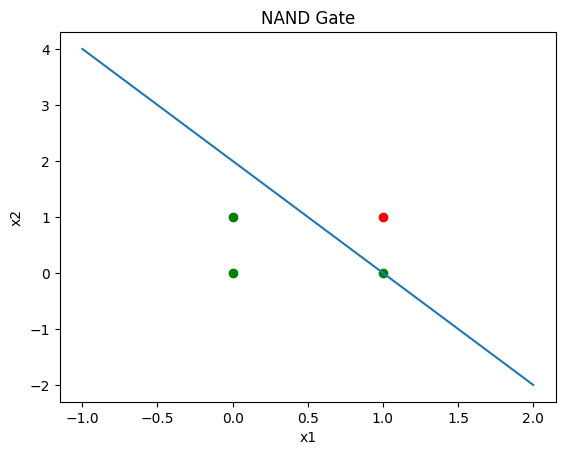

In [16]:
y = np.array([1,1,1,0])

model = Perceptron()
model.fit(X,y)

plot_decision_boundary(X,y,model,"NAND Gate")

/tmp/ipykernel_863/2485340012.py:14: RuntimeWarning: divide by zero encountered in divide
  y_vals = -(model.weights[0]*x_vals + model.bias) / model.weights[1]
/tmp/ipykernel_863/2485340012.py:14: RuntimeWarning: invalid value encountered in divide
  y_vals = -(model.weights[0]*x_vals + model.bias) / model.weights[1]


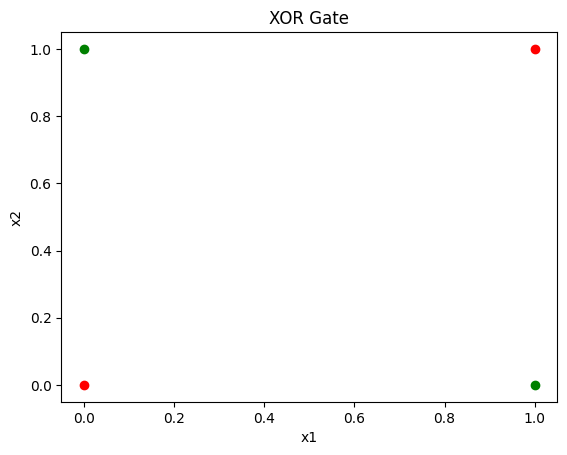

In [17]:
y = np.array([0,1,1,0])

model = Perceptron()
model.fit(X,y)

plot_decision_boundary(X,y,model,"XOR Gate")
#Fail for non linear

In [18]:
import numpy as np

# Step function
def step(x):
    return 1 if x >= 0 else 0

# Perceptron function
def perceptron(x, weights, bias):
    return step(np.dot(x, weights) + bias)

# XOR function using 2-layer logic
def XOR(x):
    # Hidden layer
    w_and = np.array([1, 1])
    b_and = -1.5

    w_or = np.array([1, 1])
    b_or = -0.5

    # Output layer
    w_out = np.array([1, -2])
    b_out = -0.5

    and_out = perceptron(x, w_and, b_and)
    or_out = perceptron(x, w_or, b_or)

    final_input = np.array([or_out, and_out])
    output = perceptron(final_input, w_out, b_out)

    return output

# Test XOR
X = np.array([[0,0],[0,1],[1,0],[1,1]])

for x in X:
    print(x, "->", XOR(x))

[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0


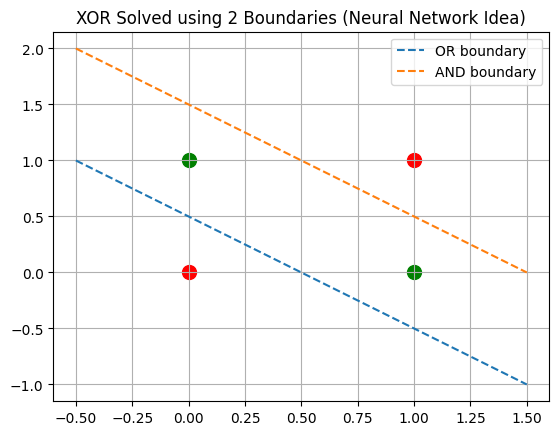

In [20]:
def plot_xor_solution():
    plt.figure()

    # XOR points
    for i in range(len(X)):
        if y[i] == 0:
            plt.scatter(X[i][0], X[i][1], color='red', s=100)
        else:
            plt.scatter(X[i][0], X[i][1], color='green', s=100)

    x_vals = np.linspace(-0.5, 1.5, 100)

    # Line 1: x1 + x2 = 0.5  (OR boundary)
    y1 = 0.5 - x_vals
    plt.plot(x_vals, y1, '--', label='OR boundary')

    # Line 2: x1 + x2 = 1.5  (AND boundary)
    y2 = 1.5 - x_vals
    plt.plot(x_vals, y2, '--', label='AND boundary')

    plt.title("XOR Solved using 2 Boundaries (Neural Network Idea)")
    plt.legend()
    plt.grid()
    plt.show()

plot_xor_solution()